In [3]:
# ======================================================
# HR ANALYTICS PROJECT - FULL DATA ANALYST WORKFLOW
# Employee Attrition Analysis
# ======================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")


In [4]:
# ======================================================
# 2. LOAD DATA
# ======================================================

df = pd.read_csv("HR_comma_sep.csv")

print("="*60)
print("DATASET SHAPE")
print(df.shape)

print("\nCOLUMNS:")
print(df.columns.tolist())


DATASET SHAPE
(14999, 10)

COLUMNS:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']


In [5]:
# ======================================================
# 3. DATA CLEANING
# ======================================================

# rename wrong column name
df.rename(columns={"average_montly_hours": "average_monthly_hours"}, inplace=True)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATES")
print(df.duplicated().sum())

# remove duplicates
df = df.drop_duplicates()

print("\nNEW SHAPE AFTER CLEANING")
print(df.shape)


MISSING VALUES
satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

DUPLICATES
3008

NEW SHAPE AFTER CLEANING
(11991, 10)


In [6]:
# ======================================================
# 4. DATA OVERVIEW
# ======================================================

print("\nINFO")
print(df.info())

print("\nDESCRIBE")
print(df.describe())


INFO
<class 'pandas.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_monthly_hours  11991 non-null  int64  
 4   time_spend_company     11991 non-null  int64  
 5   Work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   Department             11991 non-null  str    
 9   salary                 11991 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.0 MB
None

DESCRIBE
       satisfaction_level  last_evaluation  number_project  \
count        11991.000000     11991.000000    11991.000000   
mean             0.629658         0.716683        3.802852   
std              0

In [7]:
# ======================================================
# 5. KPI METRICS
# ======================================================

total_employees = len(df)
employees_left = df["left"].sum()
employees_stayed = total_employees - employees_left

attrition_rate = (employees_left / total_employees) * 100
retention_rate = 100 - attrition_rate

avg_satisfaction = df["satisfaction_level"].mean()
avg_hours = df["average_monthly_hours"].mean()

promotion_rate = df["promotion_last_5years"].mean() * 100

print("\n" + "="*60)
print("HR KPI DASHBOARD")
print("="*60)

print(f"Total Employees       : {total_employees}")
print(f"Employees Left        : {employees_left}")
print(f"Employees Stayed      : {employees_stayed}")
print(f"Attrition Rate        : {attrition_rate:.2f}%")
print(f"Retention Rate        : {retention_rate:.2f}%")
print(f"Avg Satisfaction      : {avg_satisfaction:.2f}")
print(f"Avg Monthly Hours     : {avg_hours:.2f}")
print(f"Promotion Rate        : {promotion_rate:.2f}%")


HR KPI DASHBOARD
Total Employees       : 11991
Employees Left        : 1991
Employees Stayed      : 10000
Attrition Rate        : 16.60%
Retention Rate        : 83.40%
Avg Satisfaction      : 0.63
Avg Monthly Hours     : 200.47
Promotion Rate        : 1.69%


In [9]:
# ======================================================
# 6. ATTRITION ANALYSIS
# ======================================================

print("\nATTRITION BY DEPARTMENT")
dept_attrition = df.groupby("Department")["left"].mean().sort_values(ascending=False) * 100
print(dept_attrition)

print("\nATTRITION BY SALARY")
salary_attrition = df.groupby("salary")["left"].mean().sort_values(ascending=False) * 100
print(salary_attrition)

print("\nAVG SATISFACTION BY LEFT")
print(df.groupby("left")["satisfaction_level"].mean())

print("\nAVG MONTHLY HOURS BY LEFT")
print(df.groupby("left")["average_monthly_hours"].mean())

print("\nATTRITION BY PROJECT COUNT")
print(df.groupby("number_project")["left"].mean() * 100)




ATTRITION BY DEPARTMENT
Department
hr             18.801997
accounting     17.552335
technical      17.379679
support        17.133443
sales          16.980550
marketing      16.641902
IT             16.188525
product_mng    16.034985
RandD          12.247839
management     11.926606
Name: left, dtype: float64

ATTRITION BY SALARY
salary
low       20.452962
medium    14.616993
high       4.848485
Name: left, dtype: float64

AVG SATISFACTION BY LEFT
left
0    0.667365
1    0.440271
Name: satisfaction_level, dtype: float64

AVG MONTHLY HOURS BY LEFT
left
0    198.94270
1    208.16223
Name: average_monthly_hours, dtype: float64

ATTRITION BY PROJECT COUNT
number_project
2     54.171934
3      1.079545
4      6.431479
5     15.360502
6     44.915254
7    100.000000
Name: left, dtype: float64


In [10]:
# ======================================================
# 7. FEATURE ENGINEERING
# ======================================================

df["hours_group"] = pd.cut(
    df["average_monthly_hours"],
    bins=[0,150,200,250,300,400],
    labels=["Very Low","Low","Medium","High","Extreme"]
)

print("\nATTRITION BY HOURS GROUP")
print(df.groupby("hours_group")["left"].mean() * 100)


ATTRITION BY HOURS GROUP
hours_group
Very Low     25.902062
Low           8.259349
Medium       10.633484
High         26.445211
Extreme     100.000000
Name: left, dtype: float64


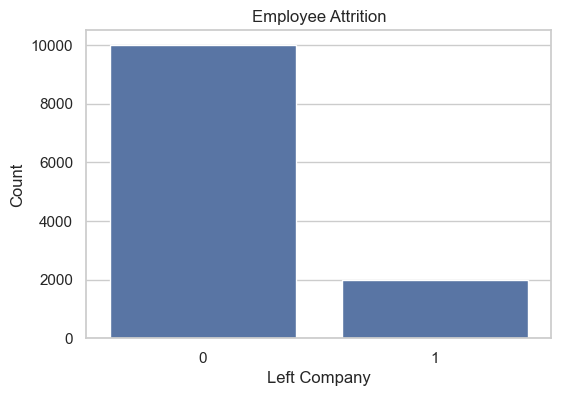

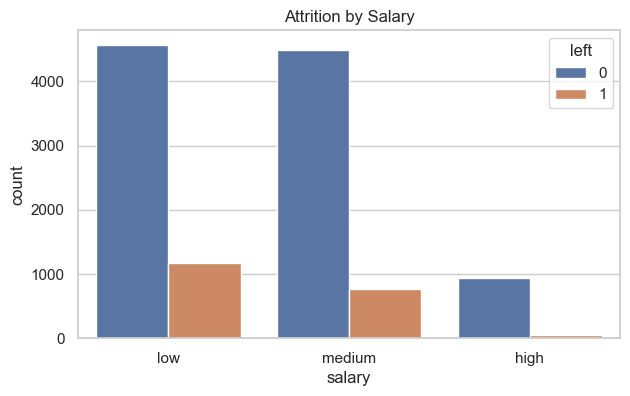

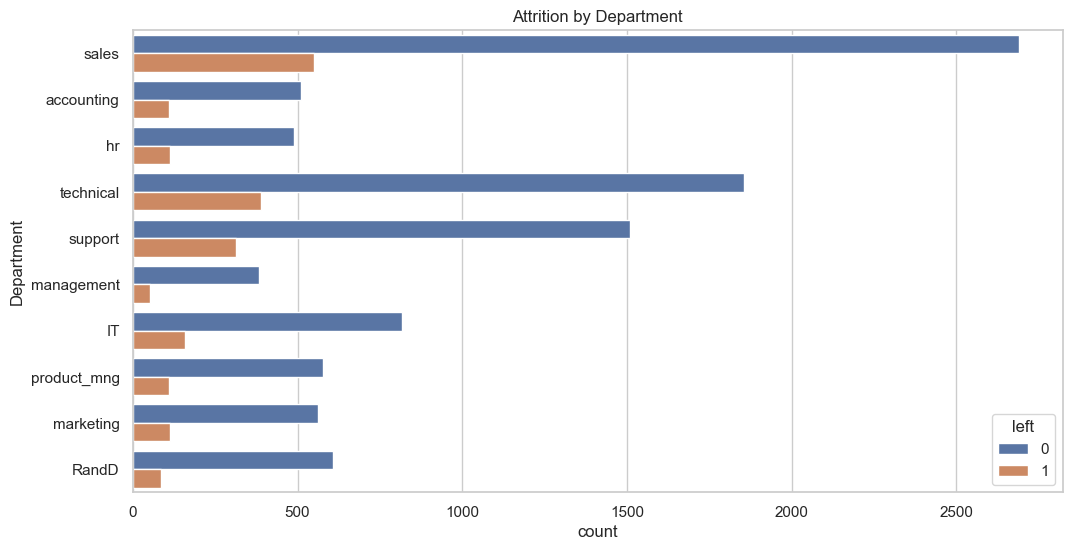

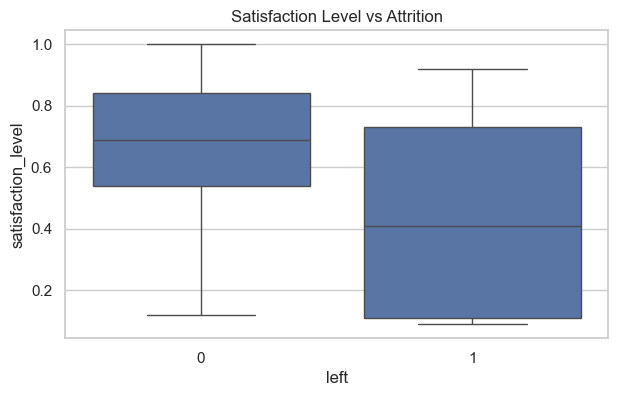

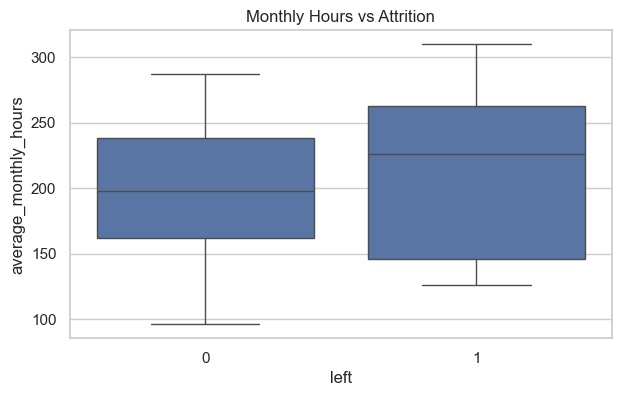

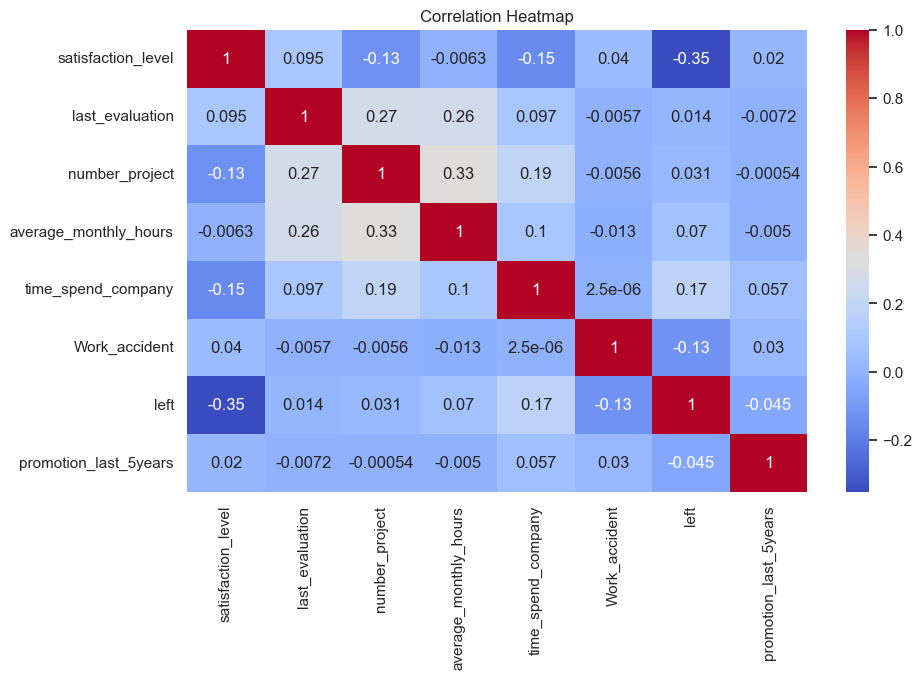

In [11]:
# ======================================================
# 8. VISUALIZATIONS
# ======================================================

# Attrition Count
plt.figure(figsize=(6,4))
sns.countplot(x="left", data=df)
plt.title("Employee Attrition")
plt.xlabel("Left Company")
plt.ylabel("Count")
plt.show()

# Attrition by Salary
plt.figure(figsize=(7,4))
sns.countplot(x="salary", hue="left", data=df)
plt.title("Attrition by Salary")
plt.show()

# Attrition by Department
plt.figure(figsize=(12,6))
sns.countplot(y="Department", hue="left", data=df)
plt.title("Attrition by Department")
plt.show()

# Satisfaction vs Attrition
plt.figure(figsize=(7,4))
sns.boxplot(x="left", y="satisfaction_level", data=df)
plt.title("Satisfaction Level vs Attrition")
plt.show()

# Monthly Hours vs Attrition
plt.figure(figsize=(7,4))
sns.boxplot(x="left", y="average_monthly_hours", data=df)
plt.title("Monthly Hours vs Attrition")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
# 9. EXECUTIVE SUMMARY
# ======================================================

print("\n" + "="*60)
print("EXECUTIVE SUMMARY")
print("="*60)

print("1. Employees with lower satisfaction are more likely to leave.")
print("2. Low salary employees have the highest attrition.")
print("3. High workload may increase resignation risk.")
print("4. Some departments need retention strategies.")
print("5. Promotions may improve retention.")


EXECUTIVE SUMMARY
1. Employees with lower satisfaction are more likely to leave.
2. Low salary employees have the highest attrition.
3. High workload may increase resignation risk.
4. Some departments need retention strategies.
5. Promotions may improve retention.


In [14]:
# 10. EXPORT CLEAN DATA
# ======================================================

df.to_csv("hr_cleaned.csv", index=False)

print("\nClean dataset exported as hr_cleaned.csv")


Clean dataset exported as hr_cleaned.csv
